# Phase 3 Step 2b — Cross-Sectional LSTM 학습 (`02b_phase15_cross_sectional.ipynb`)

> **목적**: **전체 S&P 500 universe (~624 종목)** 를 하나의 LSTM 으로 학습 (Cross-Sectional).
>          종목별 (02a) 과의 직접 비교로 "Cross-Sectional 방식의 우위 여부" 검증.

## Cross-Sectional vs 종목별 차이

| 비교 | 종목별 (02a) | **Cross-Sectional (02b)** |
|---|---|---|
| 학습 | 종목마다 별도 LSTM (624 개) | 모든 종목 공유 LSTM (1 개) |
| 정보 전달 | 종목 A 의 패턴 → A 만 | 종목 A 의 패턴 → 모든 종목 |
| Ticker 인식 | 없음 | Ticker Embedding (Gu, Kelly, Xiu 2020) |
| 파라미터 | 4,513 × 624 종목 | **~57,000 (1 모델)** |
| 데이터 효율 | 종목별 독립 | **전 종목 데이터 공유** |

## 진행 상황 가시화 (재설계, 2026-04-29)

- `tqdm.auto` fold 진행 막대 (notebook + CMD)
- fold 별 학습 완료 시 epoch / val_loss / ETA 출력 (`flush=True`)
- HAR 결합 단계도 tqdm progress

## ⭐ C4+Mj5 수정

`build_cs_inputs(align_to_common_dates=True)` 적용:
- 모든 종목 panel 전체 날짜 축으로 정렬 (IPO 이전 = NaN)
- 동일 position = 동일 market date 보장
- NaN 구간은 `_build_cs_dataset_for_fold` 에서 자동 제외

## 산출물

| 파일 | 내용 |
|---|---|
| `data/ensemble_predictions_crosssec.csv` | CS 예측 (date, ticker, y_pred_lstm_cs, y_pred_har, y_pred_ensemble, y_true) |

## 예상 시간

- **624 종목 cross-sectional**: 약 1~2 시간 (GPU 친화적, vectorized)

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 부트스트랩 |
| §2 | GPU 환경 확인 |
| §3 | C4+Mj5 날짜 정렬 검증 |
| §4 | Cross-Sectional 학습 실행 |
| §5 | 결과 검증 + Ticker Embedding 분석 |
| §6 | 02a (종목별) vs 02b (Cross-Sectional) 비교 |

## §1. 환경 부트스트랩

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR
from scripts.volatility_ensemble import build_cs_inputs
from scripts.models_cs import CrossSectionalLSTMRegressor, CS_V4_BEST_CONFIG

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '02b_crosssec'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')

  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\02b_crosssec


## §2. GPU 환경 확인

In [2]:
print('=== GPU 환경 ===')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    free_mem = (torch.cuda.get_device_properties(0).total_memory
                - torch.cuda.memory_allocated(0)) / 1e9
    print(f'Total VRAM: {total_mem:.1f} GB')
    print(f'Free  VRAM: {free_mem:.1f} GB')
    device = 'cuda'
else:
    print('⚠️ CPU 모드')
    device = 'cpu'

print(f'\n=== CS_V4_BEST_CONFIG ===')
for k, v in CS_V4_BEST_CONFIG.items():
    print(f'  {k}: {v}')

=== GPU 환경 ===
PyTorch: 2.11.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
Total VRAM: 25.8 GB
Free  VRAM: 25.8 GB

=== CS_V4_BEST_CONFIG ===
  input_size: 4
  hidden_size: 32
  num_layers: 1
  dropout: 0.3
  embedding_dim: 8
  output_dropout: 0.2
  lr: 0.0014
  weight_decay: 0.0001
  loss_type: mse
  huber_delta: 0.01
  max_epochs: 25
  early_stop_patience: 5
  lr_patience: 3
  lr_factor: 0.5
  batch_size: 512
  num_workers: 2
  is_len: 1250
  seq_len: 63
  embargo: 63
  oos_len: 21
  step: 21
  window: 21
  har_w: 5
  har_m: 22


In [3]:
# CrossSectionalLSTMRegressor 파라미터 수 확인 (전체 S&P 500: ~624 종목)
dummy_model = CrossSectionalLSTMRegressor(
    input_size=CS_V4_BEST_CONFIG['input_size'],
    hidden_size=CS_V4_BEST_CONFIG['hidden_size'],
    num_layers=CS_V4_BEST_CONFIG['num_layers'],
    dropout=CS_V4_BEST_CONFIG['dropout'],
    n_tickers=700,    # ⭐ 전체 S&P 500 (실측 624 + 안전 마진)
    embedding_dim=CS_V4_BEST_CONFIG['embedding_dim'],
)

# 컴포넌트별 파라미터 분리
n_total = sum(p.numel() for p in dummy_model.parameters())
n_emb = sum(p.numel() for n, p in dummy_model.named_parameters() if 'embedding' in n)
n_lstm = sum(p.numel() for n, p in dummy_model.named_parameters() if 'lstm' in n.lower())
n_fc = sum(p.numel() for n, p in dummy_model.named_parameters() if 'fc' in n.lower())

print(f'=== CrossSectionalLSTMRegressor 파라미터 ===')
print(f'  hidden_size: {CS_V4_BEST_CONFIG["hidden_size"]} (02a 일관)')
print(f'  num_layers:  {CS_V4_BEST_CONFIG["num_layers"]} (02a 일관)')
print(f'  embedding_dim: {CS_V4_BEST_CONFIG["embedding_dim"]}')
print(f'  n_tickers (안전): 700')
print()
print(f'  LSTM 파라미터:      {n_lstm:>8,}')
print(f'  Embedding (700×{CS_V4_BEST_CONFIG["embedding_dim"]}): {n_emb:>8,}')
print(f'  FC 파라미터:         {n_fc:>8,}')
print(f'  ---------------------------')
print(f'  Total:              {n_total:>8,}')

# ⭐ 검증: 모델이 모든 종목 학습할 만큼의 capacity 보유
# hidden=32, layers=1 환경에서 약 5,888 LSTM + 5,600 emb + 33 FC ≈ 11,500
# hidden=64, layers=2 환경에서 약 50,000+ (예전 default)
MIN_PARAMS = 5_000   # ⭐ hidden=32 환경 임계값
assert n_total >= MIN_PARAMS, f'파라미터 수 이상: {n_total} (최소 {MIN_PARAMS})'

# 02a 와 fair 비교 가능 여부 (capacity 정합성)
assert dummy_model.hidden_size == 32, f'hidden_size 불일치: {dummy_model.hidden_size}'
assert dummy_model.num_layers == 1, f'num_layers 불일치: {dummy_model.num_layers}'

print()
print('✅ 모델 구조 검증 완료 (02a 와 fair 비교 가능)')

=== CrossSectionalLSTMRegressor 파라미터 ===
  hidden_size: 32 (02a 일관)
  num_layers:  1 (02a 일관)
  embedding_dim: 8
  n_tickers (안전): 700

  LSTM 파라미터:         5,888
  Embedding (700×8):    5,600
  FC 파라미터:               33
  ---------------------------
  Total:                11,521

✅ 모델 구조 검증 완료 (02a 와 fair 비교 가능)


## §3. C4+Mj5 날짜 정렬 검증 (⭐ 핵심)

`build_cs_inputs(align_to_common_dates=True)` 를 적용했을 때
모든 종목의 date array 길이가 동일한지 검증.

- **PASS**: unique 길이가 1 → 모든 종목 동일 날짜 축
- **FAIL**: unique 길이 > 1 → 날짜 불일치 (해결 방안 §3.3 참조)


In [4]:
# 3-1. 데이터 로드 (전체 S&P 500 universe)
panel_path = DATA_DIR / 'daily_panel.csv'
universe_path = DATA_DIR / 'universe_full_history.csv'  # ⭐ 624 종목

assert panel_path.exists(), f'panel 없음: {panel_path}'
assert universe_path.exists(), f'universe 없음: {universe_path}'

panel = pd.read_csv(panel_path, parse_dates=['date'])
universe_df = pd.read_csv(universe_path, parse_dates=['cutoff_date'])

print(f'panel: {panel.shape}')
print(f'universe: {universe_df.shape}, unique {universe_df["ticker"].nunique()} 종목 (전체 S&P 500 모드)')

panel: (3344502, 17)
universe: (809, 6), unique 809 종목 (전체 S&P 500 모드)


In [5]:
# 3-2. build_cs_inputs (align=True) 실행 + 날짜 정렬 검증
# ⭐ Fair 비교 (2026-04-30): 학습과 동일한 min_data_days 사용 → 02a 일관 615 종목 검증
all_tickers = universe_df['ticker'].unique().tolist()

# 02a fair 비교 임계값 (config 기반 자동 계산)
min_days = (
    CS_V4_BEST_CONFIG['is_len']
    + CS_V4_BEST_CONFIG['seq_len']
    + CS_V4_BEST_CONFIG['oos_len']
)
print(f'학습 대상 종목 수 (universe): {len(all_tickers)}')
print(f'min_data_days = {min_days} (IS {CS_V4_BEST_CONFIG["is_len"]} + seq {CS_V4_BEST_CONFIG["seq_len"]} + OOS {CS_V4_BEST_CONFIG["oos_len"]}) — 02a 일관')
print('build_cs_inputs (align_to_common_dates=True) 실행 중...')

t0 = time.time()
cs_inputs = build_cs_inputs(
    panel=panel,
    tickers=all_tickers,
    align_to_common_dates=True,    # ⭐ C4+Mj5 수정
    min_data_days=min_days,        # ⭐ 02a 일관 615 종목 필터
)
print(f'완료 ({time.time()-t0:.1f}초)')

# 날짜 정렬 검증
date_lengths = {t: len(cs_inputs['date'][t]) for t in cs_inputs['series']}
unique_lengths = set(date_lengths.values())
print(f'=== C4+Mj5 검증 ===')
print(f'inputs 통과 종목 수: {len(cs_inputs["series"])} (02a 의 615 종목과 동일해야 정상)')
print(f'종목별 date array 길이 unique 값: {unique_lengths}')

if len(unique_lengths) == 1:
    print(f'✅ 모든 종목 동일 날짜 축 ({list(unique_lengths)[0]} 거래일)')
else:
    print(f'⚠️ 날짜 길이 불일치 ({len(unique_lengths)} 종류) — 해결 방안 §3.3 참조')
    # 주로 panel 에 없는 종목 등의 엣지 케이스
    by_len = {}
    for t, l in date_lengths.items():
        by_len.setdefault(l, []).append(t)
    for l, ts in sorted(by_len.items()):
        print(f'  length={l}: {ts[:5]}...')

if cs_inputs['common_dates'] is not None:
    print(f'common_dates: {cs_inputs["common_dates"][0].date()} ~ {cs_inputs["common_dates"][-1].date()}')

학습 대상 종목 수 (universe): 809
min_data_days = 1334 (IS 1250 + seq 63 + OOS 21) — 02a 일관
build_cs_inputs (align_to_common_dates=True) 실행 중...
완료 (80.9초)
=== C4+Mj5 검증 ===
inputs 통과 종목 수: 615 (02a 의 615 종목과 동일해야 정상)
종목별 date array 길이 unique 값: {6039}
✅ 모든 종목 동일 날짜 축 (6039 거래일)
common_dates: 2002-01-02 ~ 2025-12-31


In [6]:
# 3-3. IPO 종목 NaN 구조 확인 (예: META, Snowflake 등)
ipo_check_tickers = []
for t in all_tickers:
    if t in cs_inputs['series']:
        series = cs_inputs['series'][t]
        n_nan = np.sum(np.isnan(series))
        n_total = len(series)
        if n_nan > 500:    # 500 일 이상 NaN = 신규 IPO 가능성
            ipo_check_tickers.append((t, n_nan, n_total, round(n_nan/n_total*100, 1)))

ipo_check_tickers.sort(key=lambda x: -x[1])
print(f'NaN 구간 많은 종목 (신규 IPO 추정):')
for t, n_nan, n_total, pct in ipo_check_tickers[:10]:
    print(f'  {t}: {n_nan}/{n_total} NaN ({pct}%)')

NaN 구간 많은 종목 (신규 IPO 추정):
  MHS: 4633/6039 NaN (76.7%)
  CARR: 4585/6039 NaN (75.9%)
  OTIS: 4585/6039 NaN (75.9%)
  BEAM: 4556/6039 NaN (75.4%)
  TE: 4538/6039 NaN (75.1%)
  TEG: 4489/6039 NaN (74.3%)
  DDOG: 4460/6039 NaN (73.9%)
  PTV: 4438/6039 NaN (73.5%)
  NSM: 4430/6039 NaN (73.4%)
  CRWD: 4391/6039 NaN (72.7%)


## §4. Cross-Sectional 학습 실행 (전체 S&P 500)

`run_ensemble_cross_sectional()`:
- `use_har=True` → HAR-RV 결합 (Ensemble)
- 단일 LSTM (vectorized GPU) → 02a 보다 GPU 효율 ↑
- 학습 시간: 약 1~2 시간

> 💡 fold 진행률 + ETA 가 실시간 출력됩니다 (tqdm + flush).

In [7]:
from scripts.volatility_ensemble import run_ensemble_cross_sectional

print('=== Cross-Sectional 학습 시작 ===')
print(f'입력 채널: {CS_V4_BEST_CONFIG["input_size"]} ch (rv_d, rv_w, rv_m, vix_log)')
print(f'hidden_size: {CS_V4_BEST_CONFIG["hidden_size"]}')
print(f'embedding_dim: {CS_V4_BEST_CONFIG["embedding_dim"]}')
print(f'IS: {CS_V4_BEST_CONFIG["is_len"]}일, embargo: {CS_V4_BEST_CONFIG["embargo"]}일')

=== Cross-Sectional 학습 시작 ===
입력 채널: 4 ch (rv_d, rv_w, rv_m, vix_log)
hidden_size: 32
embedding_dim: 8
IS: 1250일, embargo: 63일


In [8]:
# (선택) 학습 데이터 사전 진단 — target_logrv NaN/inf 확인
# ⭐ 정리 (2026-04-30): §1 의 DATA_DIR import 사용 (상대 경로 중복 정의 제거)
# ※ 02b 학습 함수 내부에서 isfinite 필터로 자동 차단 — 본 셀은 단순 모니터링 용도

# panel 은 §3-1 (Cell 7) 에서 이미 로드됨 → 재사용
print('=== 학습 데이터 사전 진단 ===')

# 1. target_logrv NaN/inf 확인
n_target_nan = panel['target_logrv'].isna().sum()
n_target_inf = np.isinf(panel['target_logrv']).sum()
print(f'  target_logrv NaN: {n_target_nan:,}')
print(f'  target_logrv inf: {n_target_inf:,} (build_cs_inputs 내부 isfinite 로 자동 차단)')

# 2. Feature columns NaN/inf 확인 (panel 컬럼이 있을 때만)
print()
features = ['log_ret', 'rv_d', 'rv_w', 'rv_m', 'vix_log', 'vix']
for col in features:
    if col in panel.columns:
        n_nan = panel[col].isna().sum()
        n_inf = np.isinf(panel[col].fillna(0)).sum()
        print(f'  {col}: NaN={n_nan:,}, inf={n_inf:,}')

=== 학습 데이터 사전 진단 ===
  target_logrv NaN: 13,566
  target_logrv inf: 3,151 (build_cs_inputs 내부 isfinite 로 자동 차단)

  log_ret: NaN=646, inf=0
  vix: NaN=0, inf=0


In [ ]:
# §1.5 Panel Forward 확장 (1회 실행, 재실행 시 자동 skip)
# ⭐ 2026-05-01 추가: Panel 끝점을 forward 확장 → 마지막 fold y_true 채움
#    LSTM 의 y_true = 다음 21일 변동성 → panel 끝점 부족 시 마지막 1개월 학습 누락
#    이 셀 1회 실행 → daily_panel.csv, market_data.csv, vix_daily.csv 갱신
from scripts.universe_extended import extend_panel_forward

PANEL_END_DATE = '2026-04-30'   # ⭐ 원하는 panel 끝점

stats = extend_panel_forward(
    end_date=PANEL_END_DATE,
    backup=True,        # 기존 파일 .bak 백업
    verbose=True,
)
print(f'\n📊 Panel: {stats["panel_old_max"]} → {stats["panel_new_max"]}')
print(f'📊 추가 행: {stats["n_added_rows"]:+,d}')
print('\n다음 단계: Cell 8 (학습 셀) 의 INCREMENTAL_TRAIN=True 확인 후 실행')

In [ ]:
t0 = time.time()

# ⭐ Incremental 학습 (2026-05-01 추가, panel 확장 후 마지막 + 신규 fold 만)
INCREMENTAL_TRAIN = True   # ⭐ panel forward 확장 후 True. 사용 후 False 권장.

if INCREMENTAL_TRAIN:
    print('⚡ Cross-Sectional Incremental 학습 (panel 확장 후 마지막 + 신규 fold 만)')
    print('  ~5 fold 학습 → ~30-60분 (single GPU)')
    ensemble_cs = run_ensemble_cross_sectional(
        panel_csv=panel_path,
        universe_csv=universe_path,
        out_dir=DATA_DIR,
        config=CS_V4_BEST_CONFIG,
        device=device,
        use_har=True,
        out_name='ensemble_predictions_crosssec.csv',
        verbose=True,
        incremental=True,   # ⭐ 신규 인자
    )
else:
    ensemble_cs = run_ensemble_cross_sectional(
        panel_csv=panel_path,
        universe_csv=universe_path,           # ⭐ universe_full_history.csv (624 종목)
        out_dir=DATA_DIR,
        config=CS_V4_BEST_CONFIG,
        device=device,
        use_har=True,
        out_name='ensemble_predictions_crosssec.csv',
        verbose=True,
    )

elapsed = time.time() - t0
print(f'\n⏱️ 총 소요 시간: {elapsed/60:.1f} 분')
print(f'결과: {ensemble_cs.shape}')
print(f'  date 범위: {ensemble_cs["date"].min().date()} ~ {ensemble_cs["date"].max().date()}')
ensemble_cs.head()

## §5. 결과 검증 + Ticker Embedding 분석

In [10]:
# 5-1. 기본 통계
print('=== 결과 기본 통계 ===')
print(f'행 수: {len(ensemble_cs):,}')
print(f'unique 종목: {ensemble_cs["ticker"].nunique()}')
print(f'date 범위: {ensemble_cs["date"].min().date()} ~ {ensemble_cs["date"].max().date()}')
print()
pred_cols = [c for c in ensemble_cs.columns if 'y_pred' in c]
print(f'예측 컬럼: {pred_cols}')
print('NaN 수:')
print(ensemble_cs[pred_cols + ['y_true']].isna().sum())

=== 결과 기본 통계 ===
행 수: 2,635,610
unique 종목: 615
date 범위: 2007-04-23 ~ 2025-12-01

예측 컬럼: ['y_pred_lstm_cs', 'y_pred_har', 'y_pred_ensemble']
NaN 수:
y_pred_lstm_cs          0
y_pred_har         268559
y_pred_ensemble         0
y_true                  0
dtype: int64


In [11]:
# 5-2. 종목별 RMSE
def rmse(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2)) if mask.sum() > 0 else np.nan

lstm_col = 'y_pred_lstm_cs' if 'y_pred_lstm_cs' in ensemble_cs.columns else 'y_pred_lstm'
ens_col = 'y_pred_ensemble' if 'y_pred_ensemble' in ensemble_cs.columns else lstm_col

rmse_cs = ensemble_cs.groupby('ticker').apply(
    lambda df: pd.Series({
        'rmse_lstm_cs': rmse(df['y_true'].values, df[lstm_col].values),
        'rmse_har': rmse(df['y_true'].values, df['y_pred_har'].values),
        'rmse_ensemble_cs': rmse(df['y_true'].values, df[ens_col].values),
    })
).reset_index()

print('=== CS 모델 종목별 RMSE 통계 ===')
print(rmse_cs[['rmse_lstm_cs', 'rmse_har', 'rmse_ensemble_cs']].describe())

=== CS 모델 종목별 RMSE 통계 ===
       rmse_lstm_cs   rmse_har  rmse_ensemble_cs
count    615.000000 560.000000        615.000000
mean       0.472259   0.416766          0.415976
std        0.132113   0.111031          0.125387
min        0.346007   0.306337          0.308732
25%        0.424480   0.368802          0.371883
50%        0.450595   0.399508          0.395491
75%        0.483226   0.426969          0.422758
max        2.037464   1.801124          1.983206


C:\Users\gorhk\AppData\Local\Temp\ipykernel_44792\2258477772.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_cs = ensemble_cs.groupby('ticker').apply(


In [12]:
# 5-3. Ticker Embedding PCA 시각화 (학습된 모델에서 추출)
try:
    from sklearn.decomposition import PCA

    # 최신 모델 파일 찾기
    model_files = list((DATA_DIR / 'models_cs').glob('*.pt')) if (DATA_DIR / 'models_cs').exists() else []
    if model_files:
        latest_model = max(model_files, key=lambda p: p.stat().st_mtime)
        model = CrossSectionalLSTMRegressor(
            input_size=CS_V4_BEST_CONFIG['input_size'],
            hidden_size=CS_V4_BEST_CONFIG['hidden_size'],
            num_layers=CS_V4_BEST_CONFIG['num_layers'],
            dropout=CS_V4_BEST_CONFIG['dropout'],
            n_tickers=cs_inputs['n_tickers'],
            embedding_dim=CS_V4_BEST_CONFIG['embedding_dim'],
        )
        checkpoint = torch.load(latest_model, map_location='cpu')
        model.load_state_dict(checkpoint.get('model_state_dict', checkpoint))

        # Embedding weight 추출
        emb_weights = model.ticker_embedding.weight.detach().numpy()
        ticker_names = sorted(cs_inputs['ticker_to_id'].keys(),
                              key=lambda t: cs_inputs['ticker_to_id'][t])

        pca = PCA(n_components=2)
        emb_2d = pca.fit_transform(emb_weights)

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.6, s=30)
        for i, t in enumerate(ticker_names[:30]):    # 처음 30 개만 label
            ax.annotate(t, emb_2d[i], fontsize=7, alpha=0.8)
        ax.set_title('Ticker Embedding PCA (2D)', fontsize=12)
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
        plt.tight_layout()
        plt.savefig(OUT_DIR / 'ticker_embedding_pca.png', dpi=100, bbox_inches='tight')
        plt.show()
    else:
        print('저장된 모델 파일 없음 — embedding PCA 스킵')
except Exception as e:
    print(f'Embedding PCA 실패: {e}')

저장된 모델 파일 없음 — embedding PCA 스킵


## §6. 02a (종목별) vs 02b (Cross-Sectional) 직접 비교

동일 종목·동일 기간에서 두 방식의 RMSE 직접 비교.


공통 종목 수: 613


C:\Users\gorhk\AppData\Local\Temp\ipykernel_44792\3978334029.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sw_rmse = ensemble_sw[ensemble_sw['ticker'].isin(common_tickers)].groupby('ticker').apply(
C:\Users\gorhk\AppData\Local\Temp\ipykernel_44792\3978334029.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cs_rmse_ser = ensemble_cs[ensemble_cs['ticker'].isin(common_tickers)].groupby('ticker').apply(



CS 가 더 좋은 종목: 179/613 (29.2%)
Stockwise 평균 RMSE: 0.3908
Cross-Sec 평균 RMSE: 0.4143


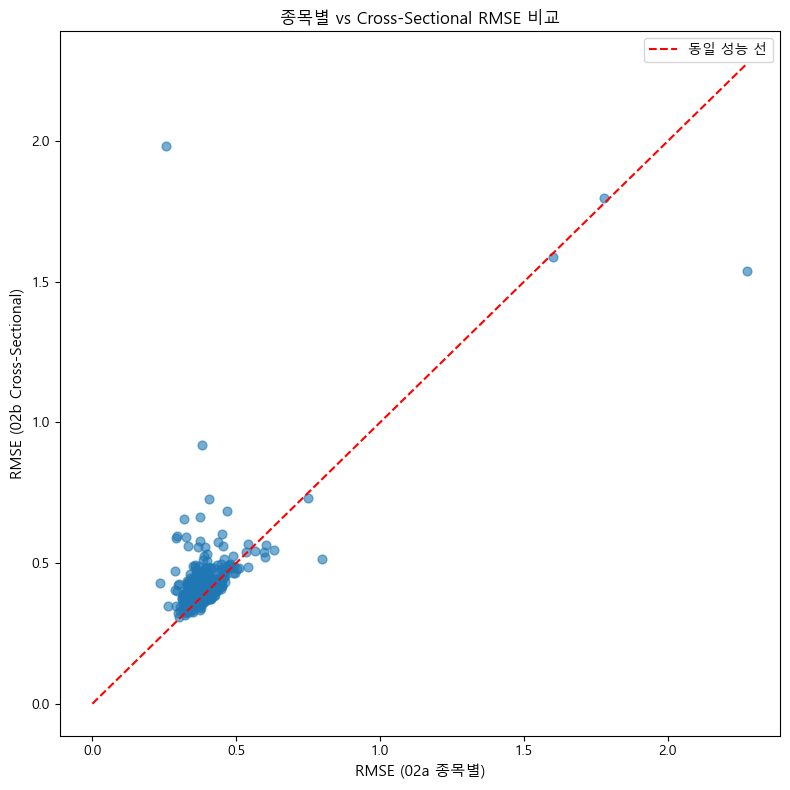

In [13]:
# 02a 결과 로드
sw_path = DATA_DIR / 'ensemble_predictions_stockwise.csv'
if sw_path.exists():
    ensemble_sw = pd.read_csv(sw_path, parse_dates=['date'])

    # 공통 종목 + 공통 기간
    common_tickers = set(ensemble_sw['ticker'].unique()) & set(ensemble_cs['ticker'].unique())
    print(f'공통 종목 수: {len(common_tickers)}')

    # 종목별 RMSE 비교
    sw_rmse = ensemble_sw[ensemble_sw['ticker'].isin(common_tickers)].groupby('ticker').apply(
        lambda df: rmse(df['y_true'].values, df['y_pred_ensemble'].values)
    ).rename('rmse_sw')

    cs_rmse_ser = ensemble_cs[ensemble_cs['ticker'].isin(common_tickers)].groupby('ticker').apply(
        lambda df: rmse(df['y_true'].values, df[ens_col].values)
    ).rename('rmse_cs')

    compare = pd.concat([sw_rmse, cs_rmse_ser], axis=1).dropna()
    compare['cs_better'] = compare['rmse_cs'] < compare['rmse_sw']

    print(f'\nCS 가 더 좋은 종목: {compare["cs_better"].sum()}/{len(compare)} ({compare["cs_better"].mean()*100:.1f}%)')
    print(f'Stockwise 평균 RMSE: {compare["rmse_sw"].mean():.4f}')
    print(f'Cross-Sec 평균 RMSE: {compare["rmse_cs"].mean():.4f}')

    # 산점도
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(compare['rmse_sw'], compare['rmse_cs'], alpha=0.6, s=40)
    lim_min = min(compare.min().min(), 0)
    lim_max = max(compare.max().max(), 0)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label='동일 성능 선')
    ax.set_xlabel('RMSE (02a 종목별)', fontsize=11)
    ax.set_ylabel('RMSE (02b Cross-Sectional)', fontsize=11)
    ax.set_title('종목별 vs Cross-Sectional RMSE 비교', fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'sw_vs_cs_rmse.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print(f'02a 결과 없음: {sw_path}')
    print('02a 학습 완료 후 재실행하십시오.')

In [14]:
# 최종 요약
print('=== Phase 3 Step 2b 완료 ===')
print(f'산출물: {DATA_DIR / "ensemble_predictions_crosssec.csv"}')
print(f'종목 수: {ensemble_cs["ticker"].nunique()}')
print(f'기간: {ensemble_cs["date"].min().date()} ~ {ensemble_cs["date"].max().date()}')
print()
print('다음 단계:')
print('  03_BL_backtest_extended.ipynb  (BL 백테스트 — 02a + 02b 완료 후)')

=== Phase 3 Step 2b 완료 ===
산출물: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data\ensemble_predictions_crosssec.csv
종목 수: 615
기간: 2007-04-23 ~ 2025-12-01

다음 단계:
  03_BL_backtest_extended.ipynb  (BL 백테스트 — 02a + 02b 완료 후)
